# Gradient descent on the confusion plane
### the label-noise story in two numbers — no embeddings required

The main lab notebook (`label_noise_sim.ipynb`) watches the policy as a point in a 2D
*feature/embedding* plane and its loss landscape in boundary coordinates $(\varphi, d)$. This
companion answers a simpler question: **is the embedding necessary?** For *convergence* questions —
does the loop reach a good policy, where does label noise park it, what does re-adjudication buy —
it is not. Everything can be watched in two numbers any reviewer already understands:

- $t$ = **catch rate** (true-positive rate): the share of real violations the policy flags.
  $1-t$ is the miss rate — every miss is a *misaligned positive*.
- $u$ = **clear rate** (true-negative rate): the share of benign items the policy leaves alone.
  $1-u$ is the over-enforcement rate — every over-flag is a *misaligned negative*.

**The two objectives, stated once.**
1. **Decision quality** — maximize macro-F1, i.e. drive both miss rate and over-enforcement rate
   down: move toward the corner $(1,1)$.
2. **A policy document that generalizes** — the F1 you *measure* during tuning must be the F1 the
   *real world* experiences. Mislabeled SME labels split these two: the loop climbs the surface it
   can measure while deployment pays out on the one it can't.

| section | question it answers |
|---|---|
| §1 | the plane: axes, height = 1 − macro-F1, and why the anchor pool *is* the distance left |
| §2 | what "boundary angle $\varphi$" meant in the code — and what this plane forgets |
| §3 | learning = climbing to the corner (clean labels), with a built-in learning-rate decay |
| §4 | corruption: silenced vs sabotage anchors, and the **stall law** $t^\* = 1-\rho$, verified |
| §5 | why re-adjudication (and why deweighting alone can't finish the job) |
| §6 | the two objectives in (small) math + what this means for the real crank |
| §7 | takeaways |

Mapping to the real crank: policy = prompt/guideline document · misaligned item = FN or FP under
the current policy · anchor = misaligned item selected for the next edit · accepted step = gated
policy edit · corruption = wrong SME labels. All trajectories below are real `labelsim` crank runs
(judge panel, confidence, gate — everything), only *replotted* in these coordinates.

In [1]:

import sys, dataclasses, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PKG = Path.cwd().resolve().parent            # sim/label-noise
if str(PKG) not in sys.path:
    sys.path.insert(0, str(PKG))

from labelsim import (CrankConfig, NoiseConfig, ReadjConfig, build_world,
                      clean_labels, run_crank)
from labelsim.experiments import base_config
from labelsim.metrics import macro_f1
from labelsim.policy import LogisticPolicy, fit_oracle

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 13

cfg0 = base_config("genai", seed=SEED, cycles=40)
ds, _ = build_world(cfg0)
PI = float((ds.y == 1).mean())               # prevalence of the violative class
NPOS = int((ds.y == 1).sum())

def confusion_point(pol, X, y):
    # a policy's whole life in two numbers, measured against label set y
    pred = pol.predict(X)
    t = float((pred[y == 1] == 1).mean())    # catch rate  (TPR)
    u = float((pred[y == 0] == 0).mean())    # clear rate  (TNR)
    return t, u

def trajectory(res, y=None):
    # replay a run's per-cycle policy snapshots as a path on the plane;
    # y=None scores against ground truth, else against the given label set
    y = res["ds"].y if y is None else y
    return np.array([confusion_point(p, res["ds"].X, y) for p in res["snapshots"]])

def macro_f1_plane(t, u, pi=PI, rho=0.0):
    # analytic macro-F1 at true position (t, u) when a fraction rho of TRUE
    # POSITIVES carry a flipped (negative) human label; rho=0 = truth surface
    tp = pi * (1 - rho) * t
    fn = pi * (1 - rho) * (1 - t)
    fp = (1 - pi) * (1 - u) + pi * rho * t          # caught-but-flipped charged as FP
    tn = (1 - pi) * u + pi * rho * (1 - t)          # missed-and-flipped credited as TN
    f1_pos = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
    f1_neg = 2 * tn / np.maximum(2 * tn + fn + fp, 1e-12)
    return 0.5 * (f1_pos + f1_neg)

T, U = np.meshgrid(np.linspace(0.002, 1, 220), np.linspace(0.002, 1, 220))
HEIGHT = 1 - macro_f1_plane(T, U)                   # offset from a perfect score
FUEL = PI * (1 - T) + (1 - PI) * (1 - U)            # misalignment share

oracle = fit_oracle(ds)
t_orc, u_orc = confusion_point(oracle, ds.X, ds.y)
print(f"world: genai, n={ds.n}, prevalence pi={PI:.2f}")
print(f"oracle boundary sits at (t={t_orc:.3f}, u={u_orc:.3f}) — the classes genuinely overlap,")
print("so the reachable ceiling is the oracle's point, not the exact corner")
print(f"sanity: measured macro-F1 {macro_f1(ds.y, oracle.predict(ds.X), 2):.4f}  ==  "
      f"analytic surface {macro_f1_plane(t_orc, u_orc):.4f}")

world: genai, n=600, prevalence pi=0.50
oracle boundary sits at (t=0.890, u=0.900) — the classes genuinely overlap,
so the reachable ceiling is the oracle's point, not the exact corner
sanity: measured macro-F1 0.8950  ==  analytic surface 0.8950


## 1 · The plane: height = offset from a perfect score

A policy's position is $(t, u)$. Its quality is one number, and it is exactly the quantity you
suggested using as the vertical axis: **the gap to a perfect F1**,

$$\text{height}(t,u) \;=\; 1 - \text{macro-F1}(t,u).$$

So yes — this simplifies things, and it loses nothing: macro-F1 is a closed-form function of
$(t, u)$ and the class prevalence $\pi$, so the whole loss surface is analytic. No embedding, no
boundary coordinates. Gradient descent is a walk on the unit square, downhill toward the corner.

**The fuel identity.** The second panel below plots a different quantity — the *misalignment
share*, i.e. the fraction of the dataset the current policy and the (correct) labels disagree on:

$$\underbrace{\pi\,(1-t)}_{\text{missed violations (FN)}} \;+\; \underbrace{(1-\pi)\,(1-u)}_{\text{over-enforcements (FP)}}$$

The two panels are the same hills. That is not a coincidence — near the corner,
$1-\text{macro-F1}$ is proportional to the misalignment count. And the misalignment pool is
precisely what the crank harvests for anchors. **The distance left to the corner *is* the anchor
fuel**: the loop literally runs on its own remaining error. Corrupting labels adulterates that
fuel — which is the whole story of §4.

*One footnote before anyone climbs:* not every point on the square is reachable by an actual
boundary — where classes genuinely overlap (adult vs racy, our contested ridge) the reachable set
stops at the world's ROC frontier. The gold star in every figure marks the **oracle boundary's**
position: the real ceiling.

same hills twice: the score you optimize and the fuel you burn are the same map


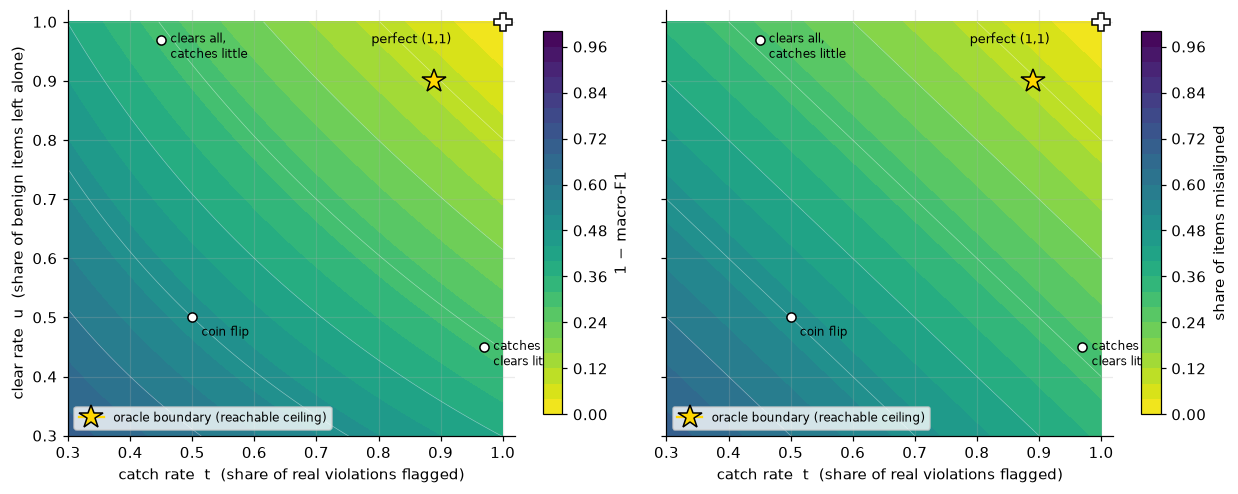

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
marks = [("coin flip", .5, .5), ("catches all,\nclears little", .97, .45),
         ("clears all,\ncatches little", .45, .97)]
for ax, Z, title, lab in (
        (axes[0], HEIGHT, "height = 1 − macro-F1 (offset from perfect)", "1 − macro-F1"),
        (axes[1], FUEL, "anchor fuel = misalignment share (FN + FP)", "share of items misaligned")):
    cs = ax.contourf(T, U, Z, levels=24, cmap="viridis_r")
    ax.contour(T, U, Z, levels=10, colors="w", linewidths=0.4, alpha=0.5)
    fig.colorbar(cs, ax=ax, label=lab, shrink=0.9)
    ax.plot(1, 1, marker="P", ms=12, color="w", mec="k", zorder=5)
    ax.annotate("perfect (1,1)", (1, 1), xytext=(-86, -14), textcoords="offset points",
                fontsize=8.5, color="k")
    ax.plot(t_orc, u_orc, marker="*", ms=16, color="gold", mec="k", zorder=5,
            label="oracle boundary (reachable ceiling)")
    for name, tx, ux in marks:
        ax.plot(tx, ux, "o", ms=6, color="w", mec="k", zorder=5)
        ax.annotate(name, (tx, ux), xytext=(6, -12), textcoords="offset points", fontsize=8)
    ax.set(xlabel="catch rate  t  (share of real violations flagged)", xlim=(0.3, 1.02),
           ylim=(0.3, 1.02))
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("clear rate  u  (share of benign items left alone)")
plt.tight_layout()
print("same hills twice: the score you optimize and the fuel you burn are the same map")

## 2 · So what was "boundary angle" in the code?

In `labelsim` the genai policy is literally a straight line in a 2D feature plane:
$\text{score}(x) = w \cdot x + b$, decide *gen\_ai* when the score is positive
(`labelsim/policy.py`, `LogisticPolicy`). Two numbers pin that line down, and the landscape
figures in the main notebook used them as coordinates:

- $\varphi = \operatorname{atan2}(w_2, w_1)$ — the compass heading of $w$, which is the boundary's
  **normal**: the direction in feature space that reads "more violative". Change $\varphi$ and the
  boundary *rotates*.
- $d = -b\,/\,\lVert w \rVert$ — how far the line sits from the origin along that normal. Change
  $d$ and the boundary *slides* sideways.

So $(\varphi, d)$ answers "**where is the line?**" — honest, but it only means something if you
can picture the embedding it lives in. The confusion plane answers "**what does the line do?**"
Every boundary maps to one $(t, u)$ point; F1 sees only outcomes, so for decision-quality
questions the plane is the right room, and the embedding can stay backstage (it is still what
*generates* the dynamics — anchors, judges and steps all live there).

**What the plane forgets** — deliberately: *which* items you miss. Two policies can sit on the
same $(t,u)$ point while failing on completely different items (the mapping is many-to-one; the
rescaled boundary below lands on exactly the oracle's dot). That identity question — do two runs
converge to the *same policy* or merely equally-good ones — is the divergence/Lyapunov agenda, and
it is the one place document-space distance still earns its keep. Convergence-to-quality: this
plane. Identifiability and chaos: keep the embedding.

rescaled boundary lands exactly on the oracle's dot: (t=0.890, u=0.900) — the plane sees outcomes, not parameters


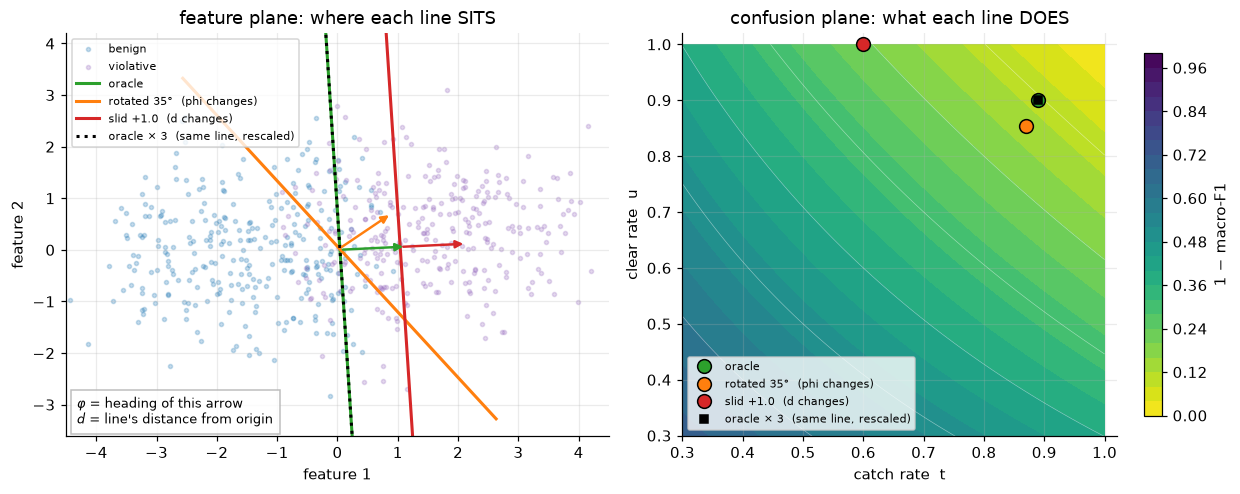

In [3]:

def rotated(pol, deg):
    th = np.deg2rad(deg)
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    return LogisticPolicy(R @ pol.w, pol.b)

def slid(pol, dz):   # slide the line dz along its normal
    return LogisticPolicy(pol.w, pol.b - dz * np.linalg.norm(pol.w))

show = [("oracle", oracle, "tab:green"),
        ("rotated 35°  (phi changes)", rotated(oracle, 35), "tab:orange"),
        ("slid +1.0  (d changes)", slid(oracle, 1.0), "tab:red"),
        ("oracle × 3  (same line, rescaled)", LogisticPolicy(3 * oracle.w, 3 * oracle.b), "k")]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
for cls, col, name in ((0, "tab:blue", "benign"), (1, "tab:purple", "violative")):
    m = ds.y == cls
    ax.scatter(ds.X[m, 0], ds.X[m, 1], s=7, alpha=0.25, color=col, label=name)
span = np.linspace(-4.2, 4.2, 2)
for name, pol, col in show:
    nw = np.linalg.norm(pol.w)
    n_hat = pol.w / nw
    p0 = -pol.b / nw * n_hat                       # closest point of the line to the origin
    d_hat = np.array([-n_hat[1], n_hat[0]])        # direction along the line
    pts = p0[None, :] + span[:, None] * d_hat[None, :]
    ls = ":" if name.startswith("oracle ×") else "-"
    ax.plot(pts[:, 0], pts[:, 1], ls, color=col, lw=2, label=name)
    if not name.startswith("oracle ×"):
        ax.annotate("", xy=p0 + 1.1 * n_hat, xytext=p0,
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=1.6))
ax.annotate(r"$\varphi$ = heading of this arrow" + "\n" + r"$d$ = line's distance from origin",
            (0.02, 0.03), xycoords="axes fraction", fontsize=8.5,
            bbox=dict(fc="w", alpha=0.85, ec="0.7"))
ax.set(title="feature plane: where each line SITS", xlabel="feature 1", ylabel="feature 2",
       xlim=(-4.5, 4.5), ylim=(-3.6, 4.2))
ax.legend(fontsize=7.5, loc="upper left")

ax = axes[1]
cs = ax.contourf(T, U, HEIGHT, levels=24, cmap="viridis_r")
ax.contour(T, U, HEIGHT, levels=10, colors="w", linewidths=0.4, alpha=0.5)
fig.colorbar(cs, ax=ax, label="1 − macro-F1", shrink=0.9)
for name, pol, col in show:
    tt, uu = confusion_point(pol, ds.X, ds.y)
    mk = "s" if name.startswith("oracle ×") else "o"
    ax.plot(tt, uu, mk, ms=9 if mk == "o" else 5, color=col, mec="k", zorder=5, label=name)
ax.set(title="confusion plane: what each line DOES", xlim=(0.3, 1.02), ylim=(0.3, 1.02),
       xlabel="catch rate  t", ylabel="clear rate  u")
ax.legend(fontsize=7.5, loc="lower left")
plt.tight_layout()
t3, u3 = confusion_point(show[3][1], ds.X, ds.y)
print(f"rescaled boundary lands exactly on the oracle's dot: (t={t3:.3f}, u={u3:.3f}) — "
      "the plane sees outcomes, not parameters")

## 3 · Learning = climbing to the corner

One crank cycle, in plane language: the judge panel reads a batch under the current policy; items
where the system vote disagrees with the human label are the **misalignments**; the top ones
(consensus × label-confidence weighted) become **anchors**; the clipped step pulls the boundary
toward the human labels; the **gate** keeps the step only if test macro-F1 doesn't drop.

- a missed violation (FN) that becomes an anchor pushes the policy **right** ($t\uparrow$),
- an over-enforcement (FP) anchor pushes it **up** ($u\uparrow$),

so with clean labels the expected motion is straight toward the corner, at a speed set by the
remaining fuel:

$$\mathbb{E}[\Delta t] \;\propto\; \eta\,\pi\,(1-t), \qquad
  \mathbb{E}[\Delta u] \;\propto\; \eta\,(1-\pi)\,(1-u).$$

Because the fuel *is* the distance left (§1), steps shrink automatically as the policy improves —
a **built-in learning-rate decay** nobody scheduled. The right panel shows the loop's own anchor
count decaying in lockstep with the true distance to the corner: the crank carries a working fuel
gauge. (The axes do couple through geometry — a step that catches one more violation can nick a
benign neighbor — which is why measured paths wiggle instead of gliding.)

seed 13: start (t=0.60, u=0.94) -> final (t=0.91, u=0.86), macro-F1 0.885  (ceiling 0.895)
seed 113: start (t=0.88, u=0.84) -> final (t=0.87, u=0.93), macro-F1 0.897  (ceiling 0.895)
seed 213: start (t=0.82, u=0.80) -> final (t=0.92, u=0.82), macro-F1 0.870  (ceiling 0.895)


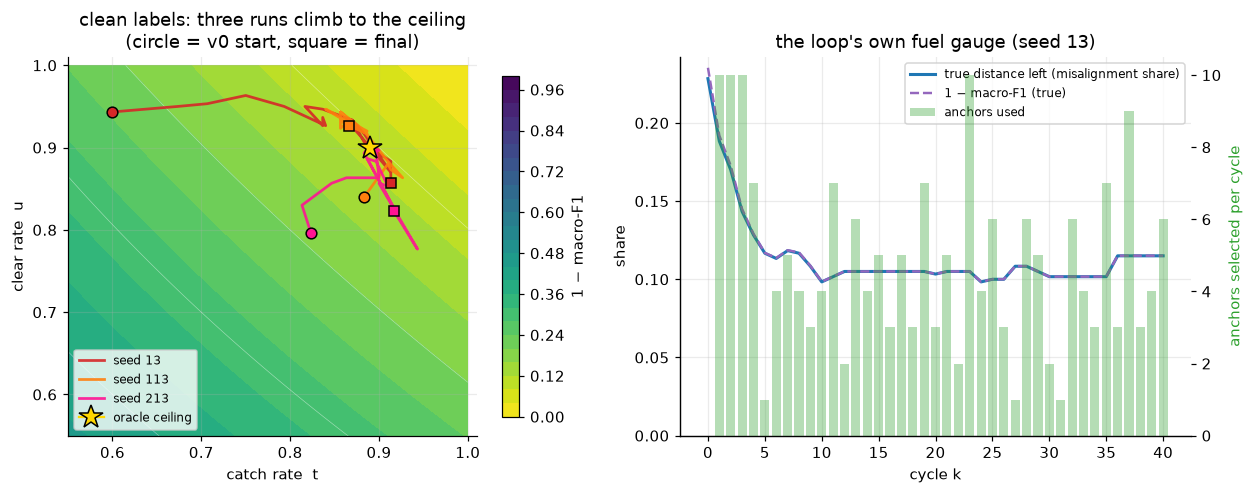

In [4]:

runs_clean = []
for s in (13, 113, 213):
    cfg_s = base_config("genai", seed=s, cycles=40)
    ds_s, _ = build_world(cfg_s)
    runs_clean.append(run_crank(cfg_s, ds=ds_s, labels=clean_labels(ds_s)))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
cs = ax.contourf(T, U, HEIGHT, levels=24, cmap="viridis_r")
ax.contour(T, U, HEIGHT, levels=10, colors="w", linewidths=0.4, alpha=0.5)
fig.colorbar(cs, ax=ax, label="1 − macro-F1", shrink=0.9)
for res, col in zip(runs_clean, ("tab:red", "tab:orange", "deeppink")):
    tr = trajectory(res)
    ax.plot(tr[:, 0], tr[:, 1], "-", color=col, lw=1.8, alpha=0.9,
            label=f"seed {res['cfg'].seed}")
    ax.plot(tr[0, 0], tr[0, 1], "o", color=col, mec="k", ms=7, zorder=5)
    ax.plot(tr[-1, 0], tr[-1, 1], "s", color=col, mec="k", ms=7, zorder=5)
ax.plot(t_orc, u_orc, marker="*", ms=16, color="gold", mec="k", zorder=6, label="oracle ceiling")
ax.set(title="clean labels: three runs climb to the ceiling\n(circle = v0 start, square = final)",
       xlabel="catch rate  t", ylabel="clear rate  u", xlim=(0.55, 1.01), ylim=(0.55, 1.01))
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
res = runs_clean[0]
tr = trajectory(res)
k = np.asarray(res["series"]["k"])
fuel_true = PI * (1 - tr[:, 0]) + (1 - PI) * (1 - tr[:, 1])
ax.plot(k, fuel_true, "-", color="tab:blue", lw=2, label="true distance left (misalignment share)")
ax.plot(k, 1 - np.asarray(res["series"]["policy_f1_true"]), "--", color="tab:purple",
        lw=1.6, label="1 − macro-F1 (true)")
ax.set(title="the loop's own fuel gauge (seed 13)", xlabel="cycle k", ylabel="share",
       ylim=(0, None))
ax2 = ax.twinx()
ax2.bar(k, res["series"]["n_anchors"], color="tab:green", alpha=0.35, label="anchors used")
ax2.set_ylabel("anchors selected per cycle", color="tab:green")
ax2.grid(False)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
plt.tight_layout()
for res in runs_clean:
    tr = trajectory(res)
    print(f"seed {res['cfg'].seed}: start (t={tr[0,0]:.2f}, u={tr[0,1]:.2f}) -> "
          f"final (t={tr[-1,0]:.2f}, u={tr[-1,1]:.2f}), macro-F1 "
          f"{res['series']['policy_f1_true'][-1]:.3f}  (ceiling {macro_f1_plane(t_orc, u_orc):.3f})")

## 4 · Corruption: two kinds of broken anchor, one stall law

Now flip a fraction of the **violative class's** human labels to benign, at random (the
directional adult→racy confusion; $\rho$ = the corrupted share of true positives). Every flipped
label lands in one of your two events, depending on what the policy currently does with the item:

- **Silenced anchor (misaligned → "aligned"): a missed learning opportunity.** The policy misses
  the item *and* the label now agrees. A real FN vanishes from the anchor pool. Fuel for
  $t\uparrow$ quietly drains — nothing pushes you further right. You don't move wrong; **you stop
  moving.** The gradient tends to zero exactly as you predicted.
- **Sabotage anchor (aligned → "misaligned"): an incorrect learning opportunity.** The policy
  *catches* the item, but the label now calls it benign. It looks like over-enforcement, so its
  anchor pulls the boundary backward to release it — a step in $-t$, off toward wherever its
  neighbors drag you. **Descent in a chaotic direction.**

Corruption at random is both events at once, in proportions set by the current position. Per true
positive, with unit anchor weights:

$$\underbrace{(1-\rho)(1-t)}_{\text{real fuel: surviving misses, pull } +t}
  \qquad\text{vs}\qquad
  \underbrace{\rho\, t}_{\text{phantom fuel: sabotaged catches, pull } -t}$$

$$\mathbb{E}[\Delta t] \;\propto\; (1-\rho)(1-t) \;-\; \rho\,t
  \;\;=\;0 \quad\Longleftrightarrow\quad \boxed{\,t^\* = 1-\rho\,}$$

**The stall law.** The loop climbs until sabotage exactly cancels real learning, then parks.
Corrupt 20% of the violative labels → the catch rate stalls near 80%. At $\rho = \tfrac12$ the
fuel cancels *everywhere*: coin-flip collapse — the same threshold the main notebook derived from
the noisy posterior (one-way rate 0.25 of all labels $\Rightarrow \rho = 0.5$ of the class).

Two things make the stall nasty: it is **self-hiding** (at $t^\*$ the anchor pool is still busy
and the gate — scoring candidates against the *same corrupted labels* — happily blesses the
backward steps), and it **caps the ceiling regardless of model quality** (more cycles, better
judges, bigger batches all still park at $1-\rho$).

*Honesty box:* this is a first-order, decoupled-axes model — it ignores geometry coupling between
$t$ and $u$, step clipping, batch/panel noise, and confidence weighting. All of those live in the
real simulated crank, so we test the law against it: the right panel runs the **full** crank
(panel, confidence, gate — no mitigations) at five corruption rates. Two forces push $-t$: the
fuel balance above, plus a tilted-yardstick pressure (next section) that rewards trading catch for
clear. So read the law as the ceiling-side prediction: final catch rate
$\lesssim \min(\text{clean ceiling},\; 1-\rho)$.

rho   law t*   gate-on t (mean±sd)   gate-on u    gate-on F1   gate-off t
0.10  0.90     0.790 ± 0.075       0.952        0.868        0.663
0.20  0.80     0.791 ± 0.077       0.960        0.874        0.544
0.30  0.70     0.677 ± 0.075       0.983        0.827        0.503
0.40  0.60     0.590 ± 0.090       0.979        0.794        0.379
0.50  0.50     0.583 ± 0.028       0.974        0.768        0.340
clean reference: t = 0.900, F1 = 0.884


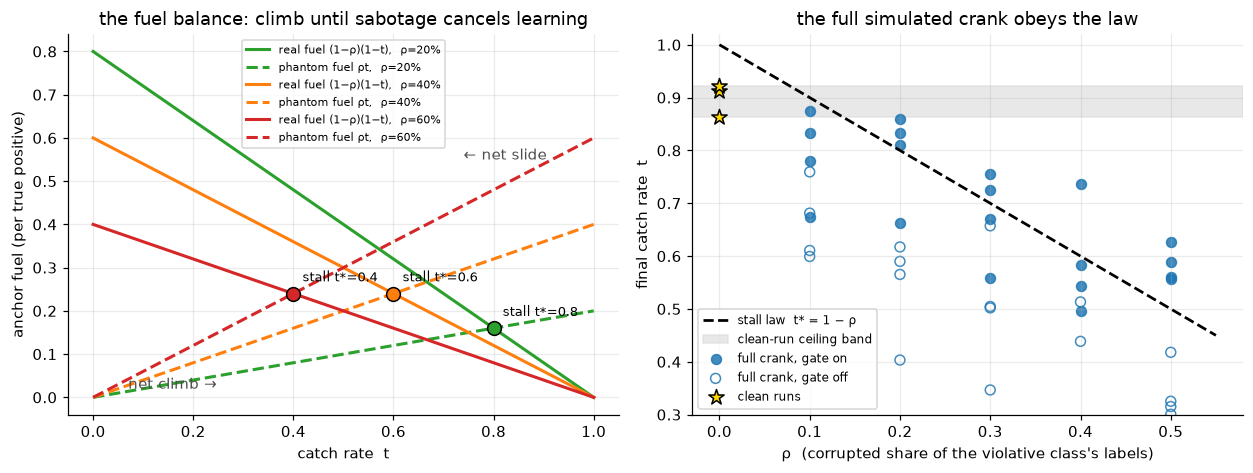

In [5]:

# left: the fuel balance; right: the full crank vs the prediction
RATES = [0.05, 0.10, 0.15, 0.20, 0.25]       # of ALL labels, one-way from class 1
SEEDS = [13, 113, 213, 313]                  # rho (share of positives) = 2 x rate here
stall_rows = []
for rate in RATES:
    for s in SEEDS:
        for gate in ("on", "off"):
            cfg = base_config("genai", seed=s, cycles=40, gate=gate,
                              noise=NoiseConfig(model="uniform", rate=rate,
                                                flip_from=1, target="both"))
            res = run_crank(cfg)
            tr = trajectory(res)
            rho_real = float(res["flipped"][res["ds"].y == 1].mean())
            stall_rows.append({"rate": rate, "seed": s, "gate": gate, "rho": rho_real,
                               "t_final": float(tr[-5:, 0].mean()),
                               "u_final": float(tr[-5:, 1].mean()),
                               "f1_true": res["series"]["policy_f1_true"][-1]})

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax = axes[0]
tt = np.linspace(0, 1, 200)
for rho, col in ((0.2, "tab:green"), (0.4, "tab:orange"), (0.6, "tab:red")):
    ax.plot(tt, (1 - rho) * (1 - tt), "-", color=col, lw=2,
            label=f"real fuel (1−ρ)(1−t),  ρ={rho:.0%}")
    ax.plot(tt, rho * tt, "--", color=col, lw=2, label=f"phantom fuel ρt,  ρ={rho:.0%}")
    ax.plot(1 - rho, rho * (1 - rho), "o", ms=9, color=col, mec="k", zorder=5)
    ax.annotate(f"stall t*={1-rho:.1f}", (1 - rho, rho * (1 - rho)),
                xytext=(6, 8), textcoords="offset points", fontsize=8.5)
ax.annotate("net climb →", (0.07, 0.02), fontsize=10, color="0.3")
ax.annotate("← net slide", (0.74, 0.55), fontsize=10, color="0.3")
ax.set(title="the fuel balance: climb until sabotage cancels learning",
       xlabel="catch rate  t", ylabel="anchor fuel (per true positive)")
ax.legend(fontsize=7.5, ncol=1)

ax = axes[1]
rho_line = np.linspace(0, 0.55, 100)
ax.plot(rho_line, 1 - rho_line, "k--", lw=1.8, label="stall law  t* = 1 − ρ")
clean_finals = [trajectory(r)[-5:, 0].mean() for r in runs_clean]
ax.axhspan(min(clean_finals), max(clean_finals), color="0.85", alpha=0.6,
           label="clean-run ceiling band")
for gate, mk, fc in (("on", "o", "tab:blue"), ("off", "o", "none")):
    rows = [r for r in stall_rows if r["gate"] == gate]
    ax.scatter([r["rho"] for r in rows], [r["t_final"] for r in rows], marker=mk,
               facecolors=fc, edgecolors="tab:blue", s=42, alpha=0.85,
               label=f"full crank, gate {gate}")
ax.scatter([0] * len(clean_finals), clean_finals, marker="*", s=110, color="gold",
           edgecolors="k", zorder=5, label="clean runs")
ax.set(title="the full simulated crank obeys the law",
       xlabel="ρ  (corrupted share of the violative class's labels)",
       ylabel="final catch rate  t", xlim=(-0.03, 0.58), ylim=(0.3, 1.02))
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()

print("rho   law t*   gate-on t (mean±sd)   gate-on u    gate-on F1   gate-off t")
for rate in RATES:
    on = [r for r in stall_rows if r["rate"] == rate and r["gate"] == "on"]
    off = [r["t_final"] for r in stall_rows if r["rate"] == rate and r["gate"] == "off"]
    rho = on[0]["rho"]
    ts = [r["t_final"] for r in on]
    print(f"{rho:.2f}  {1-rho:.2f}     {np.mean(ts):.3f} ± {np.std(ts):.3f}       "
          f"{np.mean([r['u_final'] for r in on]):.3f}        "
          f"{np.mean([r['f1_true'] for r in on]):.3f}        {np.mean(off):.3f}")
print(f"clean reference: t = {np.mean(clean_finals):.3f}, F1 = "
      f"{np.mean([r['series']['policy_f1_true'][-1] for r in runs_clean]):.3f}")

**Reading the table.** For $\rho$ = 0.2–0.5 the gated crank parks within a couple of points of
the law (measured 0.79 / 0.68 / 0.59 / 0.58 against predicted 0.80 / 0.70 / 0.60 / 0.50) — and at
the $\rho=\tfrac12$ collapse edge it sits slightly *above* it: the gate + step clipping act as a
brake, the same braking the main notebook measured. Gate-off runs (hollow) fall *below* the law
at every rate — without the gate the walk sheds structure generically, noise or no noise.

At $\rho = 0.1$ the gated crank parks below the law (0.79 vs 0.90). The diagnosis is in the $u$
column: with little sabotage fuel, the dominant force is the **tilted yardstick** — the loop
trades catch for clear along the nearly-flat F1 ridge (clear rates climb to 0.95+, true macro-F1
stays within a couple points of clean). Which exposes the operational headline:

> **Macro-F1 hides the stall.** At $\rho = 0.1$ the F1 dashboard gives up ~0.02 while the miss
> rate nearly **doubles** (catch ≈ 0.90 clean → ≈ 0.79). A production loop monitored on F1 alone
> calls this healthy. Watch the plane's *axes* (catch and clear separately), not just its
> *height* — one-way corruption converts real misses into phantom over-enforcement at a price F1
> barely registers.

### The stall is invisible from inside: where the run *is* vs where it *thinks* it is

The loop never sees $(t, u)$ — it scores itself against its own (corrupted) labels. One-way
corruption distorts the dashboard in a specific way:

$$\hat t = t \quad\text{(flips are random within the class, so the measured catch rate is fair)},
\qquad \hat u = \frac{(1-\pi)\,u + \pi\rho\,(1-t)}{(1-\pi) + \pi\rho} \;<\; u.$$

Every *caught* flipped item is charged as a false positive, so the run believes it has an
**over-enforcement problem it doesn't have** — and the sabotage anchors are precisely the loop
"fixing" that fake problem by un-catching real violations, with the gate's blessing (the gate uses
the same corrupted yardstick, so it cannot tell sabotage from genuine over-enforcement repair).

Worse, the phantom charge never clears: even at a *perfect* true clear rate ($u=1$) the dashboard
still reads $\hat u < 1$ as long as the policy catches *any* flipped item. The only "fix" the
corrupted labels accept is catching less — the tilted dashboard doesn't just misplace the
optimum, it manufactures a permanent downhill direction in $-t$. That is the chaotic slide, and
in the run below it ends with the loop clearing 100% of benign items while its catch rate has
been paid down to ~0.50.

Below: the same corrupted run drawn twice — where it really is (solid) and where its own labels
say it is (dashed), with threads connecting the two views of the same cycle.

final policy: believes macro-F1 = 0.680   truth pays 0.731   (clean twin reached 0.885)
final position: catch 0.50, clear 1.00 — it paid real catches to chase phantom clears (stall law allowed t*=0.60)


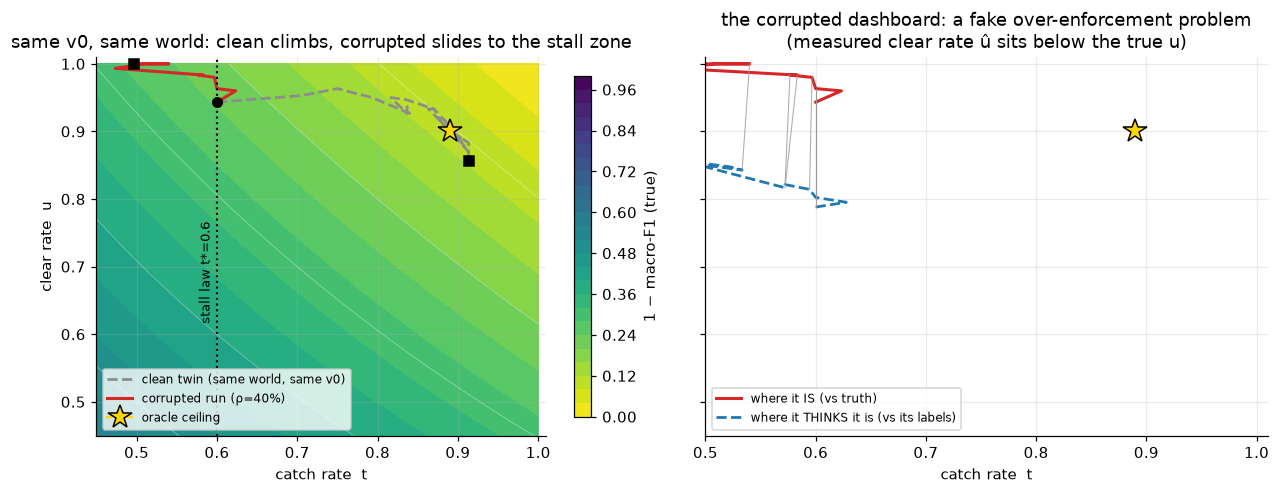

In [6]:

cfg20 = base_config("genai", seed=SEED, cycles=40,
                    noise=NoiseConfig(model="uniform", rate=0.2, flip_from=1, target="both"))
ds20, labels20 = build_world(cfg20)
res20 = run_crank(cfg20, ds=ds20, labels=labels20)      # unmitigated; readj off -> labels static
res20_clean = run_crank(cfg20, ds=ds20, labels=clean_labels(ds20))
rho20 = float(labels20[1][ds20.y == 1].mean())
tr_is = trajectory(res20)                                # measured against truth
tr_thinks = trajectory(res20, y=res20["y_human_final"])  # measured against its own labels

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
ax = axes[0]
cs = ax.contourf(T, U, HEIGHT, levels=24, cmap="viridis_r")
ax.contour(T, U, HEIGHT, levels=10, colors="w", linewidths=0.4, alpha=0.5)
fig.colorbar(cs, ax=ax, label="1 − macro-F1 (true)", shrink=0.9)
trc = trajectory(res20_clean)
ax.plot(trc[:, 0], trc[:, 1], "--", color="0.55", lw=1.8, label="clean twin (same world, same v0)")
ax.plot(tr_is[:, 0], tr_is[:, 1], "-", color="tab:red", lw=2,
        label=f"corrupted run (ρ={rho20:.0%})")
ax.axvline(1 - rho20, color="k", ls=":", lw=1.4)
ax.annotate(f"stall law t*={1-rho20:.1f}", (1 - rho20, 0.62), rotation=90, fontsize=8.5,
            xytext=(-12, 0), textcoords="offset points")
for tr in (trc, tr_is):
    ax.plot(tr[0, 0], tr[0, 1], "o", color="k", ms=6, zorder=5)
    ax.plot(tr[-1, 0], tr[-1, 1], "s", color="k", ms=6, zorder=5)
ax.plot(t_orc, u_orc, marker="*", ms=16, color="gold", mec="k", zorder=6, label="oracle ceiling")
ax.set(title="same v0, same world: clean climbs, corrupted slides to the stall zone",
       xlabel="catch rate  t", ylabel="clear rate  u", xlim=(0.45, 1.01), ylim=(0.45, 1.01))
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
ax.plot(tr_is[:, 0], tr_is[:, 1], "-", color="tab:red", lw=2, label="where it IS (vs truth)")
ax.plot(tr_thinks[:, 0], tr_thinks[:, 1], "--", color="tab:blue", lw=1.8,
        label="where it THINKS it is (vs its labels)")
for i in range(0, len(tr_is), 5):
    ax.plot([tr_is[i, 0], tr_thinks[i, 0]], [tr_is[i, 1], tr_thinks[i, 1]],
            "-", color="0.6", lw=0.7, alpha=0.8)
ax.plot(t_orc, u_orc, marker="*", ms=16, color="gold", mec="k", zorder=6)
ax.set(title="the corrupted dashboard: a fake over-enforcement problem\n"
             "(measured clear rate û sits below the true u)",
       xlabel="catch rate  t", xlim=(0.5, 1.01))
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
f1_thinks = macro_f1(res20["y_human_final"], res20["policy"].predict(ds20.X), 2)
f1_is = macro_f1(ds20.y, res20["policy"].predict(ds20.X), 2)
print(f"final policy: believes macro-F1 = {f1_thinks:.3f}   truth pays {f1_is:.3f}   "
      f"(clean twin reached {res20_clean['series']['policy_f1_true'][-1]:.3f})")
print(f"final position: catch {tr_is[-1,0]:.2f}, clear {tr_is[-1,1]:.2f} — it paid real catches "
      f"to chase phantom clears (stall law allowed t*={1-rho20:.2f})")

## 5 · Why re-adjudication — and why deweighting alone can't finish the job

Look at the anchor pool *at the stall*. The stall condition **is** "real fuel = phantom fuel", so
at equilibrium **half of the residual misalignments are label errors**, not policy errors. That is
the punchline behind sending the top residual misalignments to SMEs:

- The queue is **richest in label errors exactly when learning has stopped** — the moment
  re-adjudication is most needed is the moment it is best targeted. (An SME reviewing that queue
  should overturn just under half of it near stall; the production 33–44% overturn rates sit right
  below that ceiling, which is what a loop parked near its noise-imposed equilibrium looks like.)
- Each overturned label converts a **sabotage anchor back into an aligned item** (backward fuel
  removed) or **resurrects a silenced miss** (real fuel restored). In stall-law terms:
  re-adjudication *shrinks $\rho$ cycle by cycle, and the ceiling $t^\* = 1-\rho(k)$ lifts as the
  queue is worked.* The climb resumes and follows the rising ceiling.

**Deweighting can't do that.** Muting suspect anchors lowers the *effective* $\rho$ only as far as
the suspicion signal is accurate — and it mutes hard-but-correct labels too (S2 of the main
notebook: on MNIST, deweighting alone is *worse than nothing*). Above all, it never edits a label,
so the gate keeps scoring candidates against the same corrupted yardstick and the dashboard stays
tilted. **Weighting changes how you walk; re-adjudication redraws the map.** Confidence-weighting's
real job is routing SME attention (triage), then restoring confirmed weights — triage then repair.

clean twin                   final: catch 0.91  clear 0.86  macro-F1(true) 0.885
unmitigated                  final: catch 0.50  clear 1.00  macro-F1(true) 0.731
deweight only                final: catch 0.65  clear 0.99  macro-F1(true) 0.815
deweight + re-adjudication   final: catch 0.86  clear 0.94  macro-F1(true) 0.901
SME budget spent by the re-adj arm: 185 reviews, 82 overturned (emergent overturn rate 0.44)
residual label errors: start 120 -> end 38


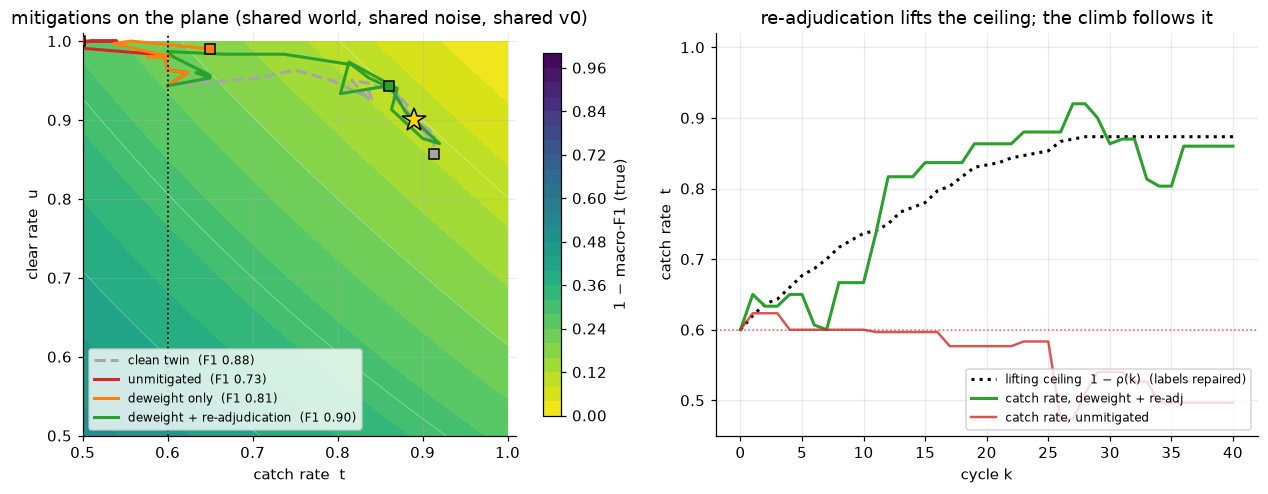

In [7]:

# four arms, one shared world + noise (rate 0.2 -> rho ~ 0.4, stall law t* ~ 0.6)
readj_cfg = dataclasses.replace(
    cfg20, readj=ReadjConfig(strategy="stack_rank", budget=5,
                             include_test=True, test_budget=5))
arms = {
    "clean twin": (run_crank(cfg20, ds=ds20, labels=clean_labels(ds20)), "0.65", "--"),
    "unmitigated": (res20, "tab:red", "-"),
    "deweight only": (run_crank(cfg20, ds=ds20, labels=labels20, weighting="deweight"),
                      "tab:orange", "-"),
    "deweight + re-adjudication": (run_crank(readj_cfg, ds=ds20, labels=labels20,
                                             weighting="deweight"), "tab:green", "-"),
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
cs = ax.contourf(T, U, HEIGHT, levels=24, cmap="viridis_r")
ax.contour(T, U, HEIGHT, levels=10, colors="w", linewidths=0.4, alpha=0.5)
fig.colorbar(cs, ax=ax, label="1 − macro-F1 (true)", shrink=0.9)
for name, (res, col, ls) in arms.items():
    tr = trajectory(res)
    f1f = res["series"]["policy_f1_true"][-1]
    ax.plot(tr[:, 0], tr[:, 1], ls, color=col, lw=2, label=f"{name}  (F1 {f1f:.2f})")
    ax.plot(tr[-1, 0], tr[-1, 1], "s", color=col, mec="k", ms=7, zorder=5)
ax.axvline(1 - rho20, color="k", ls=":", lw=1.2)
ax.plot(t_orc, u_orc, marker="*", ms=16, color="gold", mec="k", zorder=6)
ax.set(title="mitigations on the plane (shared world, shared noise, shared v0)",
       xlabel="catch rate  t", ylabel="clear rate  u", xlim=(0.5, 1.01), ylim=(0.5, 1.01))
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
res_r = arms["deweight + re-adjudication"][0]
k = np.asarray(res_r["series"]["k"])
rho_k = np.asarray(res_r["series"]["residual_label_errors"]) / NPOS
tr_r = trajectory(res_r)
tr_u = trajectory(res20)
ax.plot(k, 1 - rho_k, "k:", lw=2, label="lifting ceiling  1 − ρ(k)  (labels repaired)")
ax.plot(k, tr_r[:, 0], "-", color="tab:green", lw=2, label="catch rate, deweight + re-adj")
ax.plot(k, tr_u[:, 0], "-", color="tab:red", lw=1.6, alpha=0.8, label="catch rate, unmitigated")
ax.axhline(1 - rho20, color="tab:red", ls=":", lw=1, alpha=0.7)
ax.set(title="re-adjudication lifts the ceiling; the climb follows it",
       xlabel="cycle k", ylabel="catch rate  t", ylim=(0.45, 1.02))
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
for name, (res, _, _) in arms.items():
    tr = trajectory(res)
    print(f"{name:28s} final: catch {tr[-1,0]:.2f}  clear {tr[-1,1]:.2f}  "
          f"macro-F1(true) {res['series']['policy_f1_true'][-1]:.3f}")
print(f"SME budget spent by the re-adj arm: {res_r['reviewed_total']} reviews, "
      f"{res_r['overturned_total']} overturned "
      f"(emergent overturn rate {res_r['overturned_total']/max(res_r['reviewed_total'],1):.2f})")
print(f"residual label errors: start {int(rho_k[0]*NPOS)} -> end {int(rho_k[-1]*NPOS)}")

## 6 · The two objectives, in as little math as possible

**Objective 1 — decision quality.** The policy $\theta$ matters only through its outcomes
$(t(\theta), u(\theta))$; maximize

$$\text{DQ}(\theta) = \text{macro-F1}\big(t(\theta),\, u(\theta)\big)
\quad\Longleftrightarrow\quad \text{climb to the corner (stop at the world's ceiling ★).}$$

**What is actually observable.** With a fraction $\rho$ of the violative class's labels flipped,
the measured position is

$$\hat t = t, \qquad
  \hat u = \frac{(1-\pi)u + \pi\rho(1-t)}{(1-\pi)+\pi\rho},$$

and everything the loop consumes — anchors, gate verdicts, learning curves — is computed at
$(\hat t, \hat u)$, not $(t,u)$. The fuel balance of §4 is what that substitution does to the
*gradient*; the stall law $t^\*=1-\rho$ is what it does to the *fixed point*. And since
$\hat u < u$ whenever the policy catches *any* flipped item, the tilted dashboard doesn't just
misplace the optimum — it manufactures a permanent downhill direction in $-t$ that only
re-labeling can remove.

**Objective 2 — generalization.** The deployed number is $\text{DQ}_{\text{true}}$ evaluated
wherever climbing $\widehat{\text{DQ}}$ parked you. The **generalization gap** is the height
difference between the two surfaces at that point — in §4's figure, the horizontal thread between
"thinks" and "is". This is why the crank's split discipline exists (gate set to climb on;
locked holdout and fixed benchmark to *score* on), and why your instinct that **the validation and
test sets must be re-adjudicated too** is not optional hygiene: the gate steers by the test
labels, so corrupted test labels tilt the yardstick itself (main notebook S4: 10–20% test-only
noise → the gate false-accepts 16–20% of harmful edits; a 5-review/cycle test queue crushes that
to 1–3%).

**Multiclass** is the same picture ten times: MNIST is ten one-vs-rest planes with $\pi_c = 0.1$,
and macro-F1 is the average height across them. Per-class corruption stalls that class's own axis
at $1-\rho_c$ while the others keep climbing — which is why one corrupted *pair* (4↔9) hides so
well in aggregate metrics.

## 7 · Takeaways

1. **The embedding is not necessary for convergence questions.** $(t, u)$ = (catch rate, clear
   rate) is a complete dashboard for decision quality, and the height is exactly your suggestion:
   $1-$macro-F1, the offset from a perfect score — analytic, no simulation needed to draw the map.
   Keep the embedding/document-space view for *which-items* questions (identifiability, seed
   sensitivity, Lyapunov) — the plane deliberately can't see them.
2. **"Boundary angle" decoded:** the old coordinates were the literal line in feature space —
   $\varphi$ = heading of the boundary's normal ("which direction reads as violative"), $d$ = its
   distance from the origin. Geometry in, outcomes out: many boundaries, one $(t,u)$ point.
3. **The anchor pool is the distance to the corner.** The crank runs on its own residual
   misalignments, so steps shrink as it improves — free learning-rate decay, and a fuel gauge you
   can read in production (anchor-pool size ∝ distance left).
4. **The stall law:** corrupt a fraction $\rho$ of a class's labels at random and that class's
   catch rate parks at (or slightly below) $t^\* \approx 1-\rho$ — silenced misses drain real
   fuel, sabotaged catches burn fuel in reverse, and the loop stops where they cancel. The full
   simulated crank (panel, confidence, gate) lands within ~0.02 of the law for $\rho$ = 0.2–0.5;
   the gate brakes it just above the $\rho=\tfrac12$ coin-flip collapse, and ungated runs fall
   below the law at every rate. The stall is self-hiding: anchors stay busy, the gate stays
   satisfied.
5. **Macro-F1 hides the stall — monitor the axes, not just the height.** At $\rho = 0.1$ the loop
   gives up ~0.02 of F1 while the miss rate nearly doubles, because one-way corruption trades
   catch for clear along the nearly-flat F1 ridge. Production dashboards need catch rate and
   clear rate (equivalently FNR/FPR) tracked separately per class.
6. **At stall, half the residual misalignment queue is label errors** — so "send the most
   important residual misalignments for re-adjudication" targets the densest label-error
   population precisely when learning has stopped; production overturn rates (33–44%) sitting just
   under the 50% ceiling are the signature of a loop near equilibrium.
7. **Weighting changes how you walk; re-adjudication redraws the map.** Deweighting mutes both
   kinds of fuel and leaves the yardstick tilted. Re-adjudication shrinks $\rho(k)$, the ceiling
   $1-\rho(k)$ lifts, and the climb follows it — including on the test set, which keeps the gate
   honest. Triage with confidence, repair with SMEs.

*Companions:* `label_noise_sim.ipynb` (full suites S1–S7: dose-response, mitigation grid,
breakdown map, init sensitivity), `policy_convergence_poc.ipynb` (the formal update operator +
loader for real corrupted-vs-clean runs), `README.md` (transfer protocol to the real crank).